In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
from pathlib import Path
import matplotlib.pyplot as plt

## Loading data and helper functions

In [2]:
mg_ad_path = '/data/scRNA/RNA/Hammond/preprocessing/common_genes/GSE121654_T_concat_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 92261 × 10180
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [8]:
mg_ad.obs["batch"]

CCTCGAACGCAAGG-1-0        0
TCGGCACTCTGTGA-1-0        0
AGAGCTACTTGAGC-1-0        0
AAGGCTACCGAATC-1-0        0
GATGCAACGTGCAT-1-0        0
                         ..
CGTAGGCTCGAGAACG-1-46    46
GGGCACTTCACCAGGC-1-46    46
GGGATGATCCCAAGAT-1-46    46
CGTCTACTCTAACTTC-1-46    46
CCGGGATTCAAGAAGT-1-46    46
Name: batch, Length: 92261, dtype: category
Categories (47, object): ['0', '1', '2', '3', ..., '43', '44', '45', '46']

In [ ]:
# Embryonic batches: 0,1,2,3,4,5,6,7
# P4/P5 batches: 8,9,10,11,12,13,14,15
# P30 batches: 16,17,18,19
# P100 batches: 20,21,22,23,24,25,26,27
# Aging batches: 28,29,30,31
# P100 batches: 32,33,34
# P100 Saline batches: 35,36,37
# P100 LC batches: 38,39,40
# P5 percoll/nopercoll batches: 41,42,43,44,45,46 

In [9]:
# Define batch groups
batch_to_condition = {
    'P100-Control': [20, 21, 22, 23, 24, 25, 26, 27, 32, 33, 34],
    'P540': [28, 29, 30, 31],
    'P100-Saline': [35, 36, 37],
    'P100-LC': [38, 39, 40]
}

# Flatten and reverse map for labeling
batch_labels = {batch: label for label, batches in batch_to_condition.items() for batch in batches}

# Filter to only keep the batches listed above
keep_batches = list(batch_labels.keys())
mg_ad = mg_ad[mg_ad.obs['batch'].astype(int).isin(keep_batches)].copy()

# Assign condition labels
mg_ad.obs['condition'] = mg_ad.obs['batch'].astype(int).map(batch_labels)

In [11]:
mg_ad.obs.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,condition
TTAGGACAGAGGGCTT-1-20,20,1215,1215,1907.0,6.0,0.314630,P100-Control
CATCAAGCAATACGCT-1-20,20,2210,2210,5508.0,26.0,0.472041,P100-Control
GGCGACTTCCAAATGC-1-20,20,2174,2174,4941.0,21.0,0.425015,P100-Control
TCATTACTCGTGGACC-1-20,20,2079,2079,5006.0,29.0,0.579305,P100-Control
GCAAACTTCGGCGGTT-1-20,20,1790,1790,4642.0,8.0,0.172340,P100-Control


In [12]:
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
sc.pp.scale(mg_ad, max_value=10)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


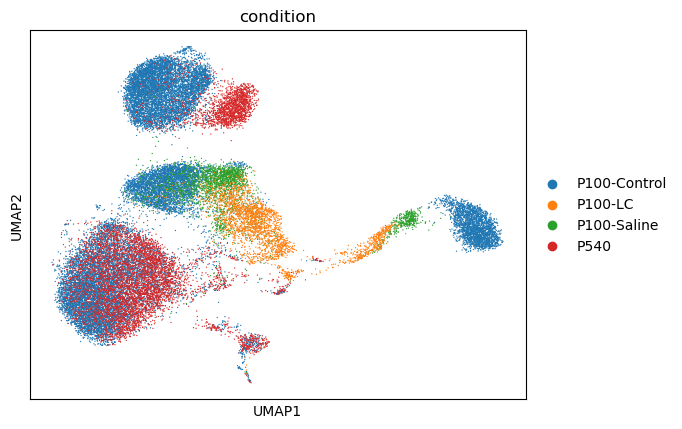

In [13]:
sc.pl.umap(mg_ad, color=['condition'])

In [6]:
# Integrate data
mg_intg = mg_ad.copy()
sc.external.pp.harmony_integrate(mg_intg, key='batch')
sc.pp.neighbors(mg_intg, use_rep='X_pca_harmony')
sc.tl.umap(mg_intg)

2025-03-14 19:08:16,959 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-03-14 19:08:21,470 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-03-14 19:08:21,576 - harmonypy - INFO - Iteration 1 of 10
2025-03-14 19:08:26,108 - harmonypy - INFO - Iteration 2 of 10
2025-03-14 19:08:32,053 - harmonypy - INFO - Converged after 2 iterations


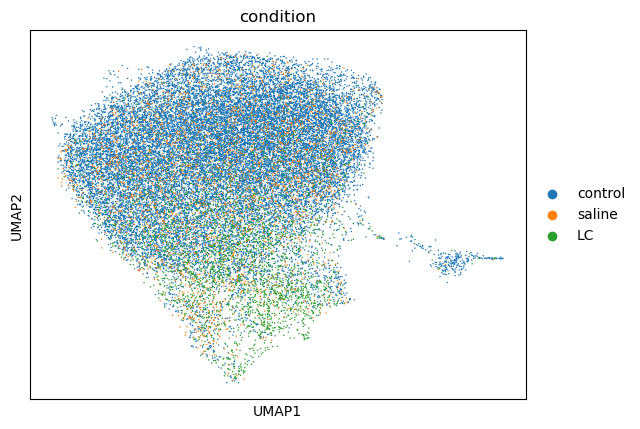

In [7]:
sc.pl.umap(mg_intg, color=['condition'])

In [14]:
# Making a dictionary of module dataframes
module_dfs = {}

# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=mg_ad.obs_names)

**Control modules**

In [15]:
# Loading data for the condition
condition = "Control"

In [16]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_normal_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_NORM-NoRP-M1,kME_NORM-NoRP-M2,kME_grey,kME_NORM-NoRP-M3,kME_NORM-NoRP-M4
Cd74,Cd74,NORM-NoRP-M1,brown,0.150583,0.419821,0.018544,0.175201,-0.040476
Apoe,Apoe,NORM-NoRP-M1,brown,0.152592,0.300385,0.036027,0.236322,-0.015315
H2.Ab1,H2.Ab1,NORM-NoRP-M2,blue,0.103400,0.393140,0.000632,0.121813,-0.045858
H2.Aa,H2.Aa,NORM-NoRP-M1,brown,0.124929,0.394893,-0.008771,0.112483,-0.048529
H2.Eb1,H2.Eb1,NORM-NoRP-M1,brown,0.120687,0.390966,-0.000478,0.119566,-0.055707


In [17]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("NORM-NoRP", "MG-Control")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Control-M1', 'MG-Control-M2', 'MG-Control-M3', 'MG-Control-M4']

In [18]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4
TTAGGACAGAGGGCTT-1-20,-0.913360,-2.281876,-3.402641,0.288517
CATCAAGCAATACGCT-1-20,0.115813,-1.601325,-0.250851,7.659016
GGCGACTTCCAAATGC-1-20,0.566422,-0.779396,0.233287,3.916189
TCATTACTCGTGGACC-1-20,0.447763,-1.930451,0.116327,6.087331
GCAAACTTCGGCGGTT-1-20,0.728452,13.192768,2.233607,-0.053933


**Saline modules**

In [19]:
# Loading data for the condition
condition = "Saline"

In [20]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_saline_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_SALINE-NoRP-M1,kME_grey,kME_SALINE-NoRP-M2,kME_SALINE-NoRP-M3
Apoe,Apoe,SALINE-NoRP-M1,blue,0.328732,0.441214,0.320913,0.270716
Ccl4,Ccl4,grey,grey,0.162866,0.414139,0.149515,0.129828
Ccl12,Ccl12,SALINE-NoRP-M1,blue,0.543086,0.105978,0.105050,0.050860
Ccl3,Ccl3,SALINE-NoRP-M1,blue,0.093986,0.320780,0.147746,0.129622
Lpl,Lpl,SALINE-NoRP-M1,blue,0.235353,0.472862,0.204790,0.199218


In [21]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("SALINE-NoRP", "MG-Saline")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Saline-M1', 'MG-Saline-M2', 'MG-Saline-M3']

In [22]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3
TTAGGACAGAGGGCTT-1-20,-0.913360,-2.281876,-3.402641,0.288517,-2.931304,-2.322103,-2.137726
CATCAAGCAATACGCT-1-20,0.115813,-1.601325,-0.250851,7.659016,-1.708933,-0.113674,2.351994
GGCGACTTCCAAATGC-1-20,0.566422,-0.779396,0.233287,3.916189,-0.573733,-0.209039,1.065775
TCATTACTCGTGGACC-1-20,0.447763,-1.930451,0.116327,6.087331,-1.702561,-0.077146,1.870791
GCAAACTTCGGCGGTT-1-20,0.728452,13.192768,2.233607,-0.053933,12.363866,-0.107806,2.358848


**ME: LC modules**

In [23]:
# Loading data for the condition
condition = "LC"

In [24]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/RNA/scRNA/Hammond/preprocessing/hdWGCNA/GO/NoRP/hdWGCNA_HVG2K_injury_NoRP_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_INJURY-NORP-M1,kME_INJURY-NORP-M2,kME_grey,kME_INJURY-NORP-M3
Ccl4,Ccl4,INJURY-NORP-M1,turquoise,0.449157,0.202290,0.093461,-0.192942
Cxcl10,Cxcl10,INJURY-NORP-M1,turquoise,0.448920,0.072827,0.053286,-0.153673
Ccl5,Ccl5,INJURY-NORP-M1,turquoise,0.306227,0.095109,0.015581,-0.194044
Ccl3,Ccl3,INJURY-NORP-M1,turquoise,0.413146,0.229298,0.095060,-0.208930
Ccl12,Ccl12,INJURY-NORP-M1,turquoise,0.496430,0.123100,0.075157,-0.224386


In [25]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("INJURY-NORP", "MG-LC")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-LC-M1', 'MG-LC-M2', 'MG-LC-M3']

In [26]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values

# Display the combined dataframe
MEs_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
TTAGGACAGAGGGCTT-1-20,-0.913360,-2.281876,-3.402641,0.288517,-2.931304,-2.322103,-2.137726,-3.116689,-2.473688,-1.099320
CATCAAGCAATACGCT-1-20,0.115813,-1.601325,-0.250851,7.659016,-1.708933,-0.113674,2.351994,-1.607117,1.890841,-0.965835
GGCGACTTCCAAATGC-1-20,0.566422,-0.779396,0.233287,3.916189,-0.573733,-0.209039,1.065775,-0.126244,0.650261,0.017160
TCATTACTCGTGGACC-1-20,0.447763,-1.930451,0.116327,6.087331,-1.702561,-0.077146,1.870791,-1.185339,1.356676,-0.762287
GCAAACTTCGGCGGTT-1-20,0.728452,13.192768,2.233607,-0.053933,12.363866,-0.107806,2.358848,12.300922,2.539574,0.199550


**Visualizing**

In [27]:
# Ensure the indices match
assert all(MEs_df.index == mg_ad.obs.index)

# Add the MEs_df to mg_ad.obs
mg_ad.obs = mg_ad.obs.join(MEs_df)

# Verify the new columns
mg_ad.obs.head()

,batch,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,condition,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
TTAGGACAGAGGGCTT-1-20,20,1215,1215,1907.0,6.0,0.314630,P100-Control,-0.913360,-2.281876,-3.402641,0.288517,-2.931304,-2.322103,-2.137726,-3.116689,-2.473688,-1.099320
CATCAAGCAATACGCT-1-20,20,2210,2210,5508.0,26.0,0.472041,P100-Control,0.115813,-1.601325,-0.250851,7.659016,-1.708933,-0.113674,2.351994,-1.607117,1.890841,-0.965835
GGCGACTTCCAAATGC-1-20,20,2174,2174,4941.0,21.0,0.425015,P100-Control,0.566422,-0.779396,0.233287,3.916189,-0.573733,-0.209039,1.065775,-0.126244,0.650261,0.017160
TCATTACTCGTGGACC-1-20,20,2079,2079,5006.0,29.0,0.579305,P100-Control,0.447763,-1.930451,0.116327,6.087331,-1.702561,-0.077146,1.870791,-1.185339,1.356676,-0.762287
GCAAACTTCGGCGGTT-1-20,20,1790,1790,4642.0,8.0,0.172340,P100-Control,0.728452,13.192768,2.233607,-0.053933,12.363866,-0.107806,2.358848,12.300922,2.539574,0.199550


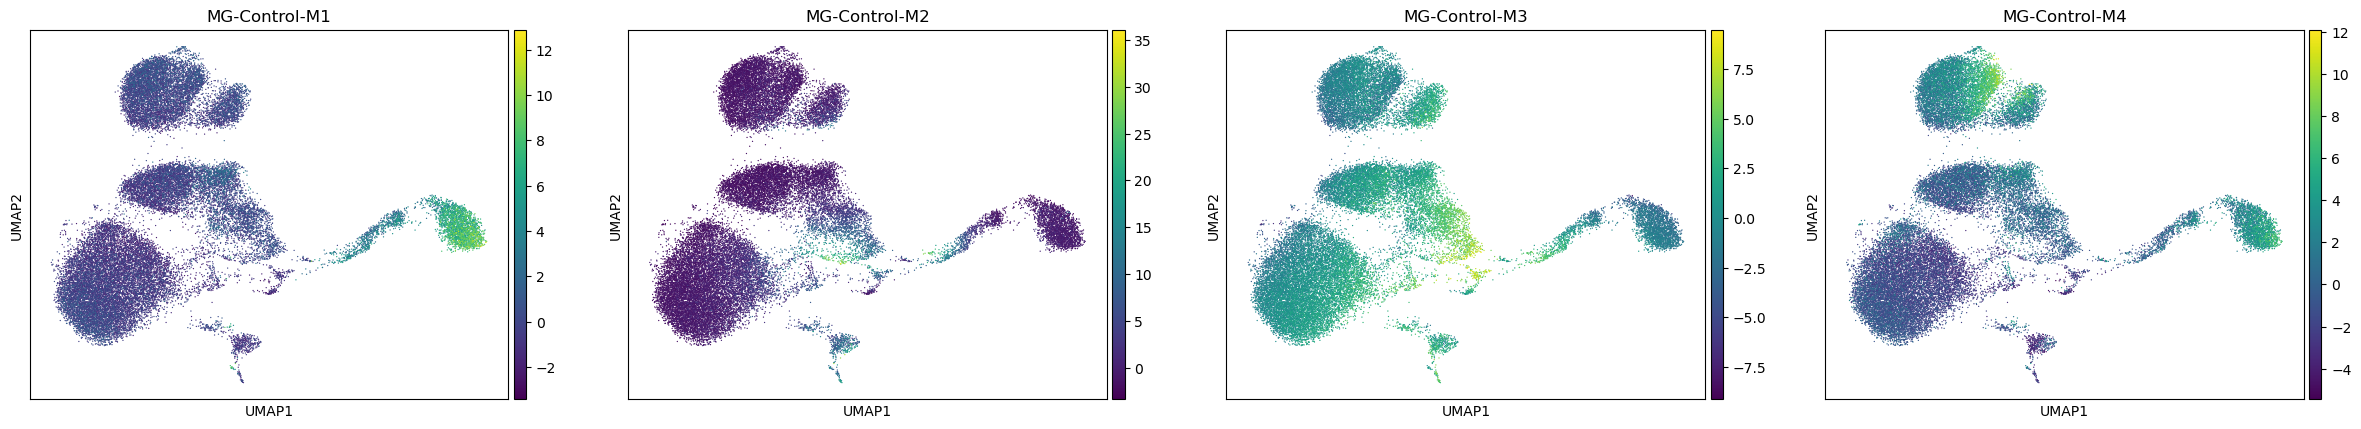

In [28]:
# Control modules
modules = module_dfs["Control"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

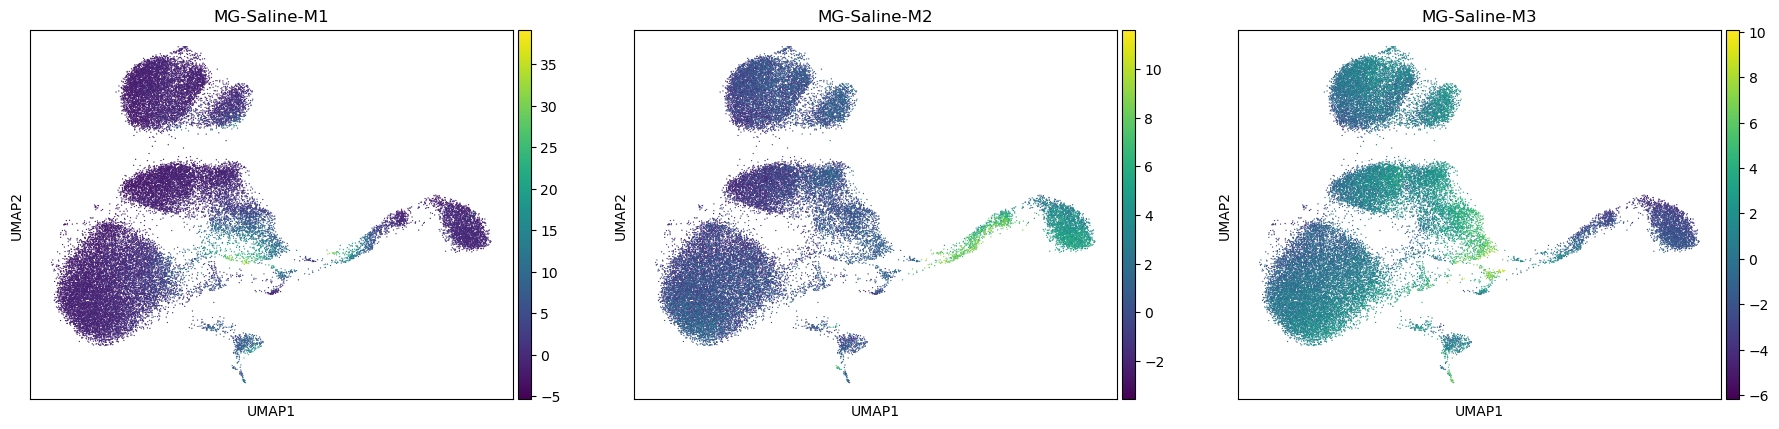

In [29]:
# Saline modules
modules = module_dfs["Saline"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

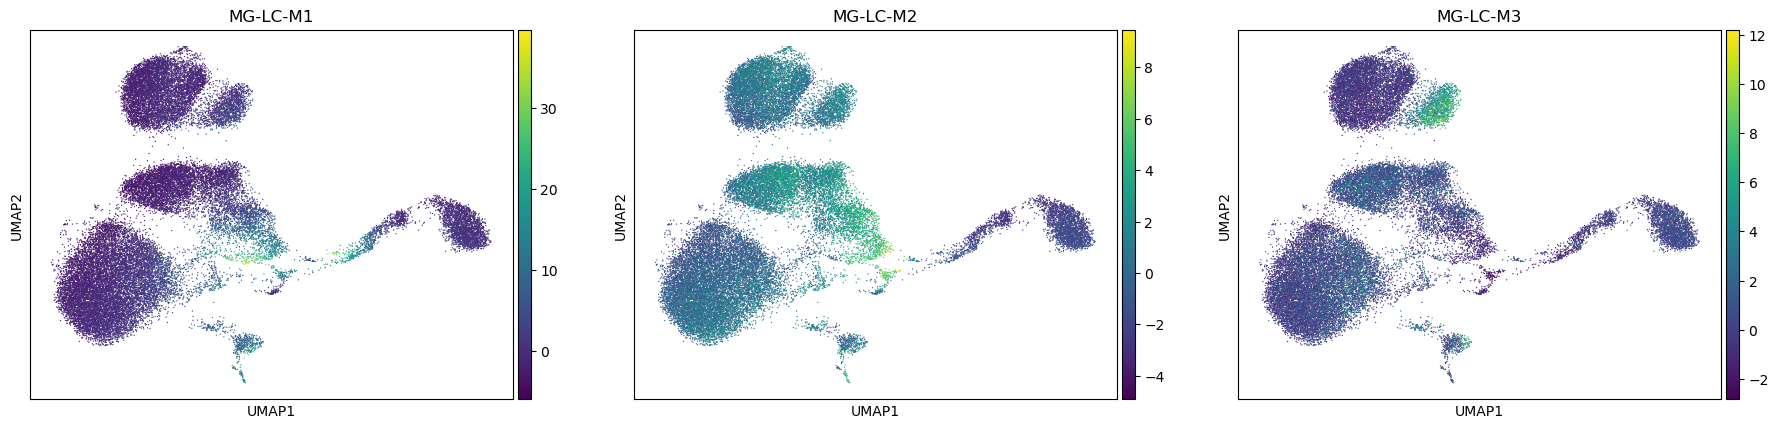

In [30]:
# LC modules
modules = module_dfs["LC"]["module"].unique().tolist()
modules.remove("grey")
sc.pl.umap(mg_ad, color=modules)

## Correlation of modules

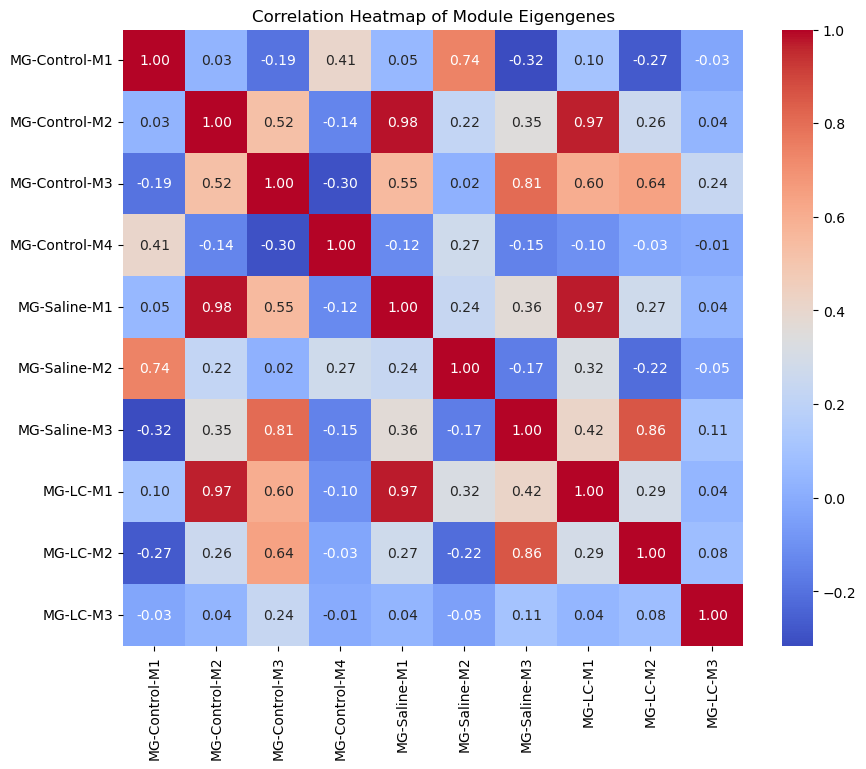

In [31]:
# Calculate the correlation matrix
corr_matrix = MEs_df.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Module Eigengenes')
plt.show()